# LangGraph 에이전트
## 도구 없음

## 라이브러리 임포트

In [1]:
# 에이전트와 통신하는 데 사용할 메시지를 정의하는 라이브러리
from langchain_core.messages import HumanMessage
# Anthropic 모델을 사용하는 라이브러리
from langchain_anthropic import ChatAnthropic
# LangGraph 프레임워크의 여러 부분을 활성화하는 라이브러리
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
# 에이전트가 반환하는 메시지의 서식 지정을 위해 사용되는 라이브러리
from IPython.display import display, Image, Markdown
# 그래프를 시각화하는 데 사용되는 라이브러리
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

## 로깅 설정

In [12]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename="../logs/langgraph_notebook.ipynb.log",
    level=logging.INFO,
)



## 에이전트와 모델 설정

In [8]:
# Anthropic 모델을 초기화한다. temperature 값은 응답의 창의성을 조절하며, 값이 낮을수록 더 예측 가능한 답변을 만든다.
# model = ChatAnthropic(
#     model="claude-3-5-sonnet-latest",
#     temperature=0,
# )
model = ChatAnthropic(
    model="claude-3-haiku-20240307",
    temperature=0,
)

# call_model 함수는 state 객체의 메시지를 모델에 전달
def call_model(state: MessagesState) -> dict:
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}
# workflow는 에이전트가 처리할 태스크를 정의
workflow = StateGraph(MessagesState)
#위에서 정의한 call_model 함수를 agent 노드로 연결
workflow.add_node("agent", call_model)
# 시작점은 바로 agent 노드로 연결
workflow.add_edge(START, 'agent')

checkpointer = MemorySaver()
# workflow를 LangChain의 Runnable 객체인 app으로 컴파일한다.
app = workflow.compile(checkpointer=checkpointer)

## 그래프 시각화하기

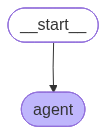

In [9]:
display(
    Image(app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API,))
)

## 에이전트와 대화하기

In [ ]:


final_state = app.invoke(
    {"messages": [HumanMessage(content="What teams did Joe Montana play for?")]},
    config={"configurable": {"thread_id": 99}},
)

display(Markdown(final_state["messages"][-1].content))

Joe Montana played for the following NFL teams:

1. San Francisco 49ers (1979-1992)
- Montana spent the majority of his Hall of Fame career with the 49ers, leading them to 4 Super Bowl championships (XVI, XIX, XXIII, XXIV).
- He is considered one of the greatest quarterbacks in NFL history.

2. Kansas City Chiefs (1993-1994)
- After retiring from the 49ers, Montana played his final two NFL seasons with the Kansas City Chiefs.

So in summary, Joe Montana's NFL teams were the San Francisco 49ers (1979-1992) and the Kansas City Chiefs (1993-1994).